# 03 - Popularity modeling

Track 2 (popularity prediction). This notebook uses the cleaned Spotify dataset and the
artist-grouped train/test split created during data preparation to predict song popularity.

We compare a simple baseline, linear regression, decision tree regression, and random forest
regression. Models are evaluated using MAE, RMSE, and R². We also compare audio-only features
against audio features plus genre to determine how much genre improves prediction.

In [39]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from src.data_prep import AUDIO_FEATURES, PROCESSED_DIR
from src import plots

plots.set_style()
pd.set_option("display.float_format", "{:,.3f}".format)

df = pd.read_csv(PROCESSED_DIR / "spotify_clean.csv")

train = df[df["split"] == "train"].copy()
test = df[df["split"] == "test"].copy()

print(f"{len(train):,} training songs")
print(f"{len(test):,} test songs")

65,040 training songs
16,141 test songs


The cleaned dataset and artist-grouped train/test split from the data preparation stage are used here. Keeping artists separated across train and test reduces leakage from repeated artist-level patterns.

## 1. Features and target

In [40]:
target = "popularity"

feature_set_a = [
    "duration_min",
    "explicit",
    "danceability",
    "energy",
    "key",
    "loudness",
    "mode",
    "speechiness",
    "acousticness",
    "instrumentalness",
    "liveness",
    "valence",
    "tempo",
    "time_signature",
    "n_artists"
]

feature_set_b = feature_set_a + ["song_genre"]

X_train_a = train[feature_set_a]
X_test_a = test[feature_set_a]

y_train = train[target]
y_test = test[target]

Feature Set A contains audio and structural song characteristics. Feature Set B adds genre. The EDA showed that audio features had relatively weak linear relationships with popularity, while genre had a much stronger association, so both feature sets are evaluated.

## 2. Baseline

In [41]:
baseline_prediction = np.repeat(y_train.mean(), len(y_test))

baseline_mae = mean_absolute_error(y_test, baseline_prediction)
baseline_rmse = mean_squared_error(y_test, baseline_prediction) ** 0.5
baseline_r2 = r2_score(y_test, baseline_prediction)

pd.Series({
    "MAE": baseline_mae,
    "RMSE": baseline_rmse,
    "R2": baseline_r2
})

MAE    16.633
RMSE   19.852
R2     -0.005
dtype: float64

The baseline model predicts the mean training-set popularity for every song. It produces an MAE of 16.63 and an RMSE of 19.85. Its R² is approximately zero, which is expected because the model does not use any song features and therefore explains essentially none of the variation in popularity.

This baseline provides a reference point for evaluating the predictive models that follow.

## 3. Linear Regression

In [42]:
def regression_metrics(y_true, y_pred):
    return {
        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": mean_squared_error(y_true, y_pred) ** 0.5,
        "R2": r2_score(y_true, y_pred)
    }

In [43]:
linear_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

linear_model.fit(X_train_a, y_train)
linear_pred = linear_model.predict(X_test_a)

regression_metrics(y_test, linear_pred)

{'MAE': 15.706705470673214,
 'RMSE': 19.11730466988606,
 'R2': 0.0682145851923237}

The linear regression model improves on the baseline, reducing MAE from 16.63 to 15.71 and RMSE from 19.85 to 19.12. However, its R² of 0.068 means that it explains only about 6.8% of the variation in song popularity.

This suggests that the audio features contain some predictive information, but simple linear relationships are not sufficient to explain popularity well. This is consistent with the exploratory analysis, which showed weak linear correlations and several nonlinear patterns.

## 4. Decision Tree Regression

In [44]:
from sklearn.model_selection import GroupKFold, GridSearchCV

groups = train["primary_artist"]

tree_model = DecisionTreeRegressor(random_state=42)

tree_param_grid = {
    "max_depth": [3, 5, 8, 10, 15, 20, None],
    "min_samples_leaf": [5, 10, 20, 50]
}

group_cv = GroupKFold(n_splits=5)

tree_search = GridSearchCV(
    estimator=tree_model,
    param_grid=tree_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    n_jobs=-1
)

tree_search.fit(
    X_train_a,
    y_train,
    groups=groups
)

print("Best parameters:", tree_search.best_params_)
print("Best CV RMSE:", -tree_search.best_score_)

Best parameters: {'max_depth': 10, 'min_samples_leaf': 50}
Best CV RMSE: 18.29997209696107


In [45]:
best_tree = tree_search.best_estimator_

tree_pred = best_tree.predict(X_test_a)

regression_metrics(y_test, tree_pred)

{'MAE': 14.960798930389455,
 'RMSE': 18.68518220170791,
 'R2': 0.10986216838870044}

The Decision Tree performed better than both the baseline and the Linear Regression model. Using grouped cross-validation, the best configuration was a maximum depth of 10 with a minimum of 50 samples per leaf. This configuration produced a cross-validation RMSE of about 18.30.

On the held-out test set, the Decision Tree achieved an MAE of about 14.96, an RMSE of about 18.69, and an R² of about 0.110. This means the model explains roughly 11% of the variation in song popularity.

Compared with Linear Regression, the Decision Tree reduced prediction error and achieved a higher R², suggesting that nonlinear relationships between song characteristics and popularity are important.

## 5. Random Forest Regression

In [46]:
rf_model = RandomForestRegressor(
    random_state=42,
    n_jobs=-1
)

rf_param_grid = {
    "n_estimators": [100],
    "max_depth": [10, 15],
    "min_samples_leaf": [5, 10]
}

rf_search = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=group_cv,
    n_jobs=-1
)

rf_search.fit(
    X_train_a,
    y_train,
    groups=groups
)

print("Best parameters:", rf_search.best_params_)
print("Best CV RMSE:", -rf_search.best_score_)

Best parameters: {'max_depth': 15, 'min_samples_leaf': 10, 'n_estimators': 100}
Best CV RMSE: 17.747532294260388


In [47]:
best_rf = rf_search.best_estimator_

rf_pred_a = best_rf.predict(X_test_a)

regression_metrics(y_test, rf_pred_a)

{'MAE': 14.458472343381727,
 'RMSE': 18.150358363652142,
 'R2': 0.16008953269335569}

The Random Forest model achieved the strongest performance so far. Using grouped cross-validation, the best configuration used 100 trees, a maximum depth of 15, and a minimum of 10 samples per leaf. This configuration produced a cross-validation RMSE of about 17.75.

On the held-out test set, the Random Forest achieved an MAE of about 14.46, an RMSE of about 18.15, and an R² of about 0.160. This means the model explains approximately 16% of the variation in song popularity.

The Random Forest outperformed both the Linear Regression and Decision Tree models, suggesting that nonlinear relationships and interactions between song features improve popularity prediction.

## 6. Random Forest with Genre

In [48]:
numeric_features = feature_set_a
categorical_features = ["song_genre"]

preprocessor = ColumnTransformer([
    ("numeric", "passthrough", numeric_features),
    ("genre", OneHotEncoder(handle_unknown="ignore"), categorical_features)
])

In [49]:
rf_genre_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestRegressor(
        **rf_search.best_params_,
        random_state=42,
        n_jobs=-1
    ))
])

rf_genre_model.fit(
    train[feature_set_b],
    y_train
)

rf_pred_b = rf_genre_model.predict(
    test[feature_set_b]
)

regression_metrics(y_test, rf_pred_b)

{'MAE': 13.159132361427533,
 'RMSE': 16.95032092192573,
 'R2': 0.2674817731409368}

Adding genre noticeably improved the Random Forest model. Using the same tuned Random Forest settings as the audio-only model, the model with genre achieved an MAE of about 13.16, an RMSE of about 16.95, and an R² of about 0.267.

Compared with the audio-only Random Forest, adding genre reduced the RMSE from about 18.15 to 16.95 and increased R² from about 0.160 to 0.267. This indicates that genre provides substantial predictive information beyond the song's audio and structural characteristics.

The improvement is consistent with the exploratory analysis, which showed that genre had a much stronger relationship with popularity than most individual audio features.

## 7. Model Comparison

In [50]:
results = pd.DataFrame([
    {"Model": "Baseline", **regression_metrics(y_test, baseline_prediction)},
    {"Model": "Linear Regression", **regression_metrics(y_test, linear_pred)},
    {"Model": "Decision Tree", **regression_metrics(y_test, tree_pred)},
    {"Model": "RF - Audio", **regression_metrics(y_test, rf_pred_a)},
    {"Model": "RF - Audio + Genre", **regression_metrics(y_test, rf_pred_b)}
])

results_sorted = results.sort_values("RMSE").reset_index(drop=True)

results_sorted

,Model,MAE,RMSE,R2
0,RF - Audio + Genre,13.159,16.950,0.267
1,RF - Audio,14.458,18.150,0.160
2,Decision Tree,14.961,18.685,0.110
3,Linear Regression,15.707,19.117,0.068
4,Baseline,16.633,19.852,-0.005


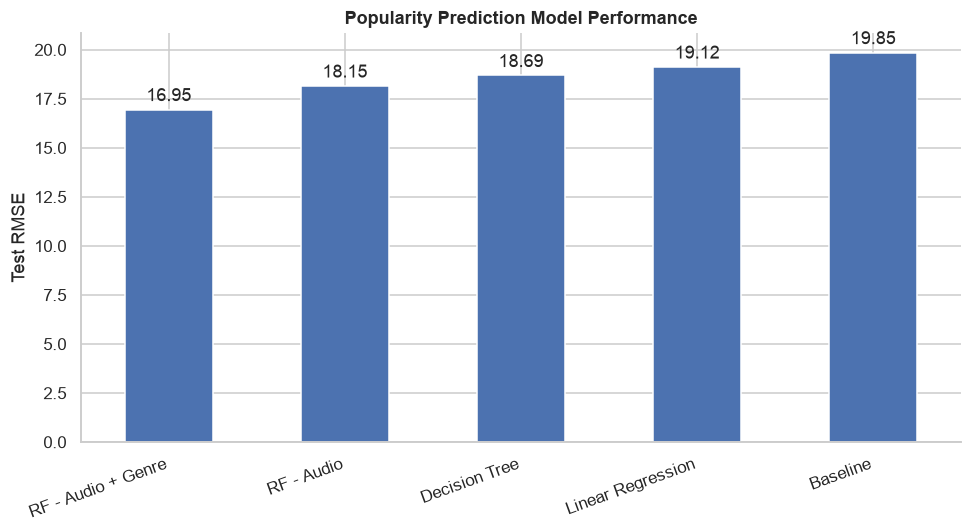

In [51]:
ax = results_sorted.plot(
    x="Model",
    y="RMSE",
    kind="bar",
    legend=False,
    figsize=(9, 5)
)

ax.set_ylabel("Test RMSE")
ax.set_xlabel("")
ax.set_title("Popularity Prediction Model Performance")

for container in ax.containers:
    ax.bar_label(container, fmt="%.2f", padding=3)

plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

The Random Forest model that included both audio features and genre achieved the best overall performance, with the lowest RMSE of about 16.95, the lowest MAE of about 13.16, and the highest R² of about 0.267.

Performance improved as the models became more capable of capturing nonlinear relationships. Linear Regression improved slightly over the baseline, the Decision Tree improved further, and the audio-only Random Forest performed better than the single tree.

The largest improvement came from adding genre to the Random Forest. RMSE decreased from about 18.15 to 16.95, while R² increased from about 0.160 to 0.267. This suggests that genre provides important predictive information beyond the audio and structural characteristics of a song.

Although the best model improves substantially over the baseline, an R² of about 0.267 also shows that a large portion of song popularity remains unexplained by the available features.

## 8. Feature Importance

In [52]:
importance = pd.Series(
    best_rf.feature_importances_,
    index=feature_set_a
).sort_values(ascending=False)

importance

instrumentalness   0.153
acousticness       0.142
duration_min       0.108
speechiness        0.088
loudness           0.087
danceability       0.085
valence            0.081
energy             0.078
tempo              0.060
liveness           0.051
n_artists          0.025
key                0.020
explicit           0.011
mode               0.008
time_signature     0.004
dtype: float64

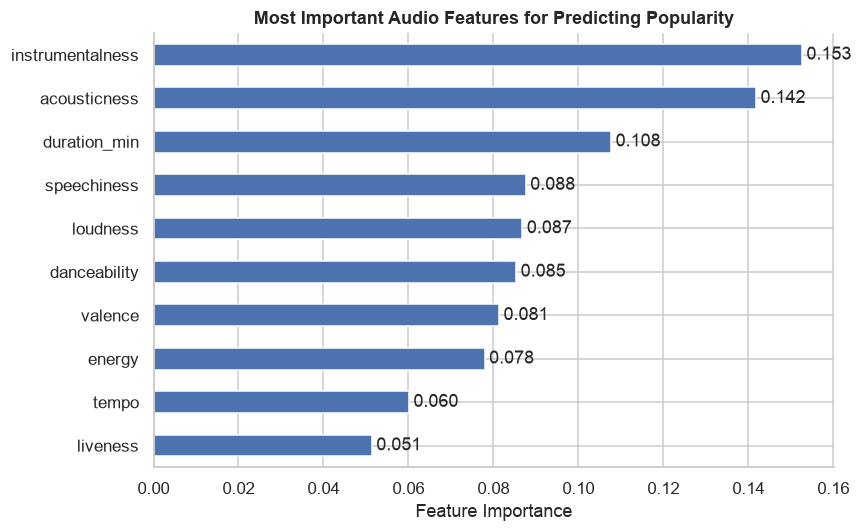

In [53]:
ax = importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

ax.set_xlabel("Feature Importance")
ax.set_title("Most Important Audio Features for Predicting Popularity")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

The audio-only Random Forest identified instrumentalness, acousticness, and song duration as the most important predictors of popularity. Instrumentalness had the highest feature importance at about 0.153, followed by acousticness at about 0.142 and duration at about 0.108.

Speechiness, loudness, danceability, valence, and energy also contributed to the model, while features such as explicit status, mode, and time signature had relatively little influence.

These importance values indicate which features the Random Forest relied on most when making predictions. However, feature importance does not show whether a feature increases or decreases popularity, and it should not be interpreted as a causal relationship.

### Best-Model Feature Importance

In [54]:
from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_genre_model,
    test[feature_set_b],
    y_test,
    scoring="neg_root_mean_squared_error",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

best_model_importance = pd.Series(
    perm_importance.importances_mean,
    index=feature_set_b
).sort_values(ascending=False)

best_model_importance

song_genre          3.827
instrumentalness    0.921
energy              0.211
n_artists           0.172
loudness            0.044
speechiness         0.038
acousticness        0.030
danceability        0.014
liveness            0.006
duration_min        0.005
tempo               0.003
key                 0.002
mode                0.001
time_signature      0.000
explicit           -0.001
valence            -0.002
dtype: float64

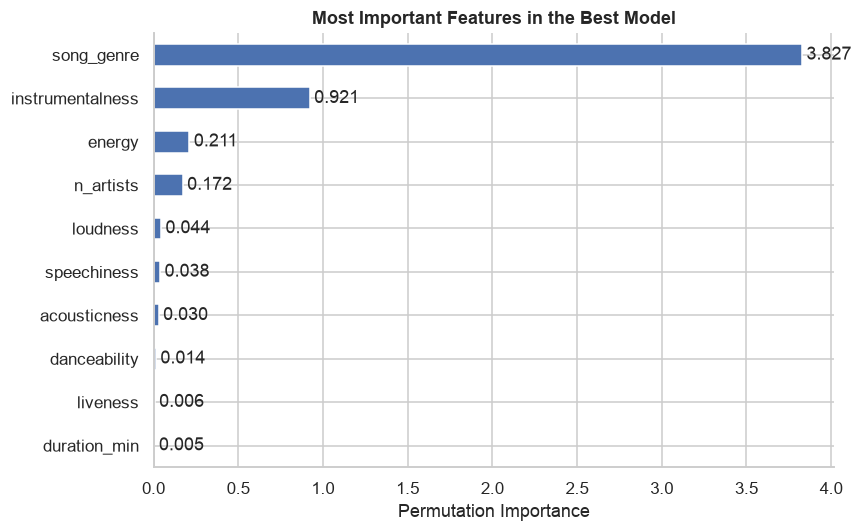

In [55]:
ax = best_model_importance.head(10).sort_values().plot(
    kind="barh",
    figsize=(8, 5)
)

ax.set_xlabel("Permutation Importance")
ax.set_title("Most Important Features in the Best Model")

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=3)

plt.tight_layout()
plt.show()

Permutation importance for the best-performing Random Forest model shows that genre was by far the most influential predictor of song popularity. Shuffling `song_genre` produced the largest decrease in model performance, with an importance of about 3.83, followed by instrumentalness at about 0.92.

Energy and number of artists also contributed to prediction, while the remaining features had much smaller effects. This reinforces the earlier model comparison, where adding genre substantially improved RMSE and R² compared with the audio-only Random Forest.

These values should be interpreted as measures of how much the model depends on each feature for accurate prediction. They do not indicate the direction of the relationship or imply that changing a feature will directly cause popularity to increase or decrease.

## 9. Prediction Errors

In [56]:
best_pred = rf_pred_b

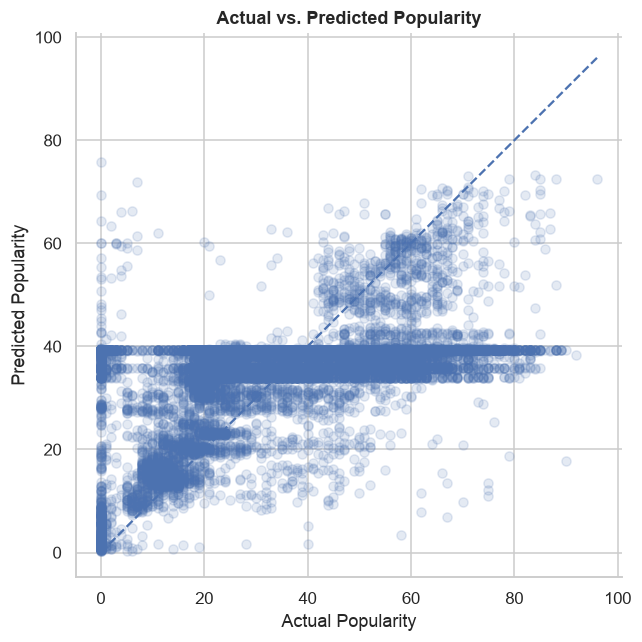

In [57]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, best_pred, alpha=0.15)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs. Predicted Popularity")

plt.tight_layout()
plt.show()

The actual-versus-predicted plot shows that the model captures the overall direction of popularity, but predictions are concentrated near the middle of the popularity range. Low-popularity songs are often overpredicted, while highly popular songs are often underpredicted.

The dashed diagonal line represents perfect predictions, where predicted popularity would exactly match actual popularity. The distance of many observations from this line shows that substantial prediction error remains, particularly at the extremes of the popularity scale.

This indicates that the model has difficulty predicting extreme popularity values, which is consistent with its R² of about 0.267. Although the model improves substantially over the baseline, much of the variation in popularity remains unexplained. This suggests that factors not included in the dataset, such as artist recognition, promotion, playlist exposure, or other market-related influences, may also contribute to song popularity.

## 10. Findings

The Random Forest model using both audio characteristics and genre produced the strongest overall results. It achieved an MAE of about 13.16, an RMSE of about 16.95, and an R² of about 0.267 on the held-out test set. This was a clear improvement over the baseline model, as well as the Linear Regression, Decision Tree, and audio-only Random Forest models.

The progression in model performance suggests that song popularity is influenced by relationships that are not captured well by a simple linear model. Both the Decision Tree and Random Forest improved on Linear Regression, while the ensemble Random Forest performed better than the individual Decision Tree.

Genre provided the largest improvement in predictive performance. Adding genre to the audio-only Random Forest reduced RMSE from about 18.15 to 16.95 and increased R² from about 0.160 to 0.267. Permutation importance also showed that `song_genre` was by far the most influential feature in the best-performing model, followed by instrumentalness. Energy and the number of artists also contributed to prediction, while most other features had smaller effects.

Among the audio characteristics alone, instrumentalness, acousticness, and song duration were the most important predictors in the audio-only Random Forest. These results indicate which characteristics were most useful to the models, but they should not be interpreted as evidence that changing one feature will directly cause a song to become more popular.

Despite outperforming the other models, the final model explains only about 26.7% of the variation in popularity. The actual-versus-predicted results also show that the model tends to overpredict songs with very low popularity and underpredict highly popular songs. This suggests that genre and audio characteristics are useful predictors, but they do not fully explain Spotify popularity.

For artists and producers, these findings suggest that genre context should be considered alongside song characteristics when evaluating a track's market positioning. Features such as instrumentalness, acousticness, duration, and energy may be useful for comparing new songs with successful songs in similar genres. However, these patterns should be treated as decision-support signals rather than strict production rules, since the analysis identifies associations rather than causal effects.